In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상권변화지표 데이터 불러오기
df_변화 = pd.read_csv(
    '../data/08_상권변화지표/서울시 상권분석서비스(상권변화지표-상권).csv',
    encoding='cp949'
)

# 길단위인구 데이터 불러오기
df_인구 = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 분석 기간 필터링 (2019~2024, 24분기)
df_변화 = df_변화[df_변화['기준_년분기_코드'] < 20250]
df_인구 = df_인구[df_인구['기준_년분기_코드'] < 20250]

print("상권변화지표 shape:", df_변화.shape)
print("길단위인구 shape:", df_인구.shape)

상권변화지표 shape: (39600, 11)
길단위인구 shape: (39589, 27)


In [2]:
# 두 데이터의 고유 상권_코드 개수 비교
print("상권변화지표 고유 상권 수:", df_변화['상권_코드'].nunique())
print("길단위인구 고유 상권 수:", df_인구['상권_코드'].nunique())

# 어떤 상권이 길단위인구에 없는지 확인
변화_상권 = set(df_변화['상권_코드'].unique())
인구_상권 = set(df_인구['상권_코드'].unique())

# 변화지표엔 있는데 인구엔 없는 상권
only_변화 = 변화_상권 - 인구_상권
print("\n변화지표에만 있는 상권 수:", len(only_변화))

# 인구엔 있는데 변화지표엔 없는 상권
only_인구 = 인구_상권 - 변화_상권
print("인구에만 있는 상권 수:", len(only_인구))

상권변화지표 고유 상권 수: 1650
길단위인구 고유 상권 수: 1650

변화지표에만 있는 상권 수: 0
인구에만 있는 상권 수: 0


In [3]:
# 각 데이터의 분기별 행 수 비교
변화_분기별 = df_변화.groupby('기준_년분기_코드').size()
인구_분기별 = df_인구.groupby('기준_년분기_코드').size()

# 나란히 비교
분기비교 = pd.DataFrame({
    '변화지표': 변화_분기별,
    '길단위인구': 인구_분기별
})
분기비교['차이'] = 분기비교['변화지표'] - 분기비교['길단위인구']

print(분기비교)

           변화지표  길단위인구  차이
기준_년분기_코드                 
20191      1650   1650   0
20192      1650   1650   0
20193      1650   1650   0
20194      1650   1650   0
20201      1650   1650   0
20202      1650   1650   0
20203      1650   1650   0
20204      1650   1650   0
20211      1650   1650   0
20212      1650   1650   0
20213      1650   1650   0
20214      1650   1650   0
20221      1650   1650   0
20222      1650   1650   0
20223      1650   1650   0
20224      1650   1649   1
20231      1650   1649   1
20232      1650   1649   1
20233      1650   1649   1
20234      1650   1648   2
20241      1650   1649   1
20242      1650   1649   1
20243      1650   1648   2
20244      1650   1649   1


In [4]:
# 상권별 전체 분기 수 계산
total = df_변화.groupby('상권_코드').size()

# 상권별 상권축소 분기 수 계산
축소 = (df_변화[df_변화['상권_변화_지표_명'] == '상권축소']
        .groupby('상권_코드').size())

# 상권축소 비율 계산 (없는 상권은 0으로)
축소_비율 = (축소 / total * 100).fillna(0).round(1)

# 80~99% 구간 필터링 후 상위 20개 추출
취약상권_코드 = (축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]
                .sort_values(ascending=False)
                .head(20)
                .index.tolist())

# 상권명 매핑
코드_명_매핑 = df_변화[['상권_코드', '상권_코드_명', '상권_구분_코드_명']].drop_duplicates()

취약_df = (pd.DataFrame({'상권_코드': 취약상권_코드})
           .merge(코드_명_매핑, on='상권_코드', how='left'))

print(f"취약상권 수: {len(취약_df)}개")
print(취약_df[['상권_코드_명', '상권_구분_코드_명']])

취약상권 수: 20개
          상권_코드_명 상권_구분_코드_명
0             응봉산       골목상권
1         금동어린이공원       골목상권
2        중곡3동주민센터       골목상권
3          보문역 4번       골목상권
4         솔숲어린이공원       골목상권
5          망우역 1번       골목상권
6        응암1동주민센터       골목상권
7          금천해태공원       골목상권
8           구로보건소       골목상권
9           경기대학교       골목상권
10         송천초등학교       골목상권
11         연신내우체국       골목상권
12         신풍역 1번       골목상권
13        방배동카페골목       발달상권
14       방학동도깨비시장       전통시장
15  돌곶이시장(석관황금시장)       전통시장
16         관악신사시장       전통시장
17       디지털단지오거리       발달상권
18           성북구청       발달상권
19          난우중학교       골목상권


In [5]:
# 취약상권 코드 목록으로 길단위인구 필터링
df_취약_인구 = df_인구[df_인구['상권_코드'].isin(취약상권_코드)].copy()

# 상권명, 유형 붙이기
df_취약_인구 = df_취약_인구.merge(
    코드_명_매핑,
    on='상권_코드',
    how='inner'  # 양쪽 모두 있는 것만
)

print("shape:", df_취약_인구.shape)
print("상권 수:", df_취약_인구['상권_코드'].nunique())
print("분기 수:", df_취약_인구['기준_년분기_코드'].nunique())

shape: (480, 29)
상권 수: 20
분기 수: 24


In [7]:
# 현재 컬럼 목록 확인
print(df_취약_인구.columns.tolist())

['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명_x', '상권_코드', '상권_코드_명_x', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수', '상권_코드_명_y', '상권_구분_코드_명_y']


In [8]:
# _x 컬럼을 정리해서 이름 통일
df_취약_인구 = df_취약_인구.rename(columns={
    '상권_코드_명_x': '상권_코드_명',
    '상권_구분_코드_명_x': '상권_구분_코드_명'
})

# _y 컬럼은 중복이라 제거
df_취약_인구 = df_취약_인구.drop(columns=['상권_코드_명_y', '상권_구분_코드_명_y'])

print(df_취약_인구.columns.tolist())

['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수', '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수', '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수', '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수']


In [9]:
# 연령대 컬럼 목록 정의
연령대_컬럼 = [
    '연령대_10_유동인구_수',
    '연령대_20_유동인구_수',
    '연령대_30_유동인구_수',
    '연령대_40_유동인구_수',
    '연령대_50_유동인구_수',
    '연령대_60_이상_유동인구_수'
]

# 상권별 연령대 평균 유동인구 계산 (24분기 평균)
df_연령_평균 = (df_취약_인구
               .groupby(['상권_코드', '상권_코드_명', '상권_구분_코드_명'])[연령대_컬럼]
               .mean()
               .reset_index())

# 각 상권별 연령대 비중(%) 계산
df_연령_평균['합계'] = df_연령_평균[연령대_컬럼].sum(axis=1)
for col in 연령대_컬럼:
    df_연령_평균[col.replace('_유동인구_수', '_비중')] = (
        df_연령_평균[col] / df_연령_평균['합계'] * 100
    ).round(1)

print(df_연령_평균[['상권_코드_명'] + [c.replace('_유동인구_수', '_비중') for c in 연령대_컬럼]])

          상권_코드_명  연령대_10_비중  연령대_20_비중  연령대_30_비중  연령대_40_비중  연령대_50_비중  \
0         금동어린이공원       16.7       10.8       16.0       16.1       15.3   
1             응봉산       22.2        9.7       13.0       15.7       15.4   
2        중곡3동주민센터       11.8       13.2       16.7       14.8       17.4   
3          망우역 1번       12.5       13.5       15.6       14.4       16.9   
4         솔숲어린이공원       18.4       11.7       13.5       16.3       14.6   
5          보문역 4번       12.5       27.0       15.1       12.3       12.8   
6          송천초등학교       18.4       10.9       11.4       15.5       16.1   
7        응암1동주민센터       19.5       10.5       14.9       16.8       14.4   
8          연신내우체국       16.3       11.5       13.0       14.5       15.9   
9           경기대학교       16.7       14.6       14.6       16.1       16.0   
10          구로보건소       11.9       13.1       18.0       16.5       16.4   
11         금천해태공원        9.7       12.6       15.3       15.2       17.9   
12         신

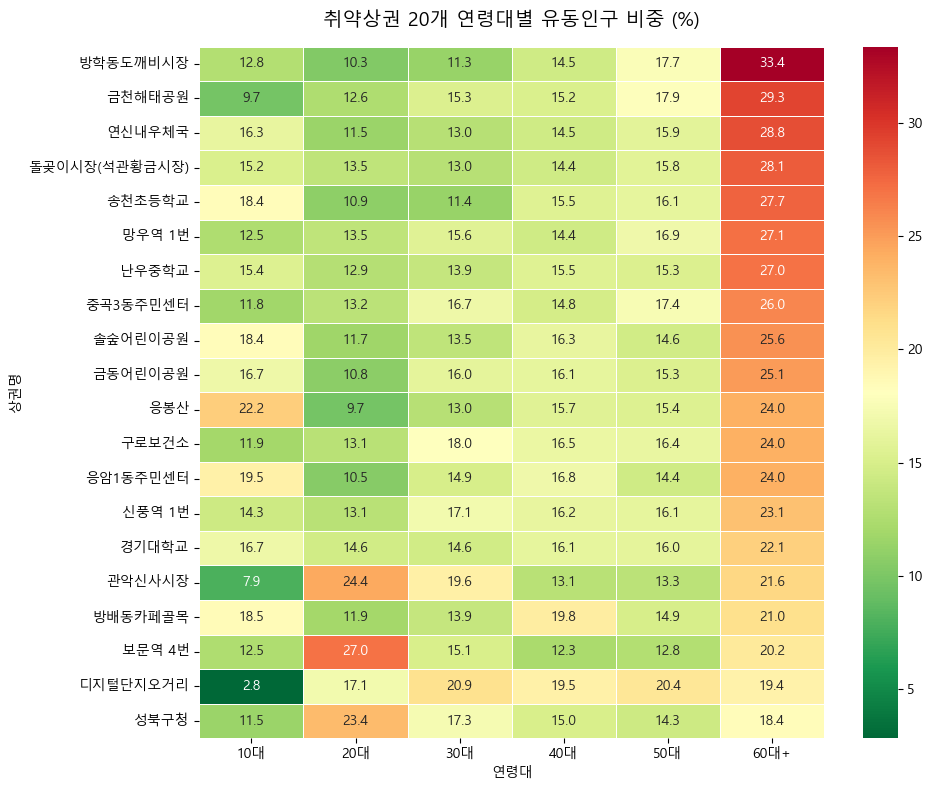

In [10]:
# 히트맵용 데이터 준비
비중_컬럼 = [c.replace('_유동인구_수', '_비중') for c in 연령대_컬럼]
df_히트맵 = df_연령_평균.set_index('상권_코드_명')[비중_컬럼]

# 컬럼명 간결하게 변경
df_히트맵.columns = ['10대', '20대', '30대', '40대', '50대', '60대+']

# 60대 비중 기준으로 정렬 (높은 순)
df_히트맵 = df_히트맵.sort_values('60대+', ascending=False)

# 히트맵 그리기
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df_히트맵,
    annot=True,          # 수치 표시
    fmt='.1f',           # 소수점 1자리
    cmap='RdYlGn_r',     # 빨강(높음) ~ 초록(낮음)
    linewidths=0.5,
    ax=ax
)

ax.set_title('취약상권 20개 연령대별 유동인구 비중 (%)', fontsize=14, pad=15)
ax.set_xlabel('연령대')
ax.set_ylabel('상권명')

plt.tight_layout()
plt.show()